In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/global_climate_energy_2020_2024.csv")

print(df.head())

         date  country  avg_temperature  humidity  co2_emission  \
0  2020-01-01  Germany            28.29     31.08        212.63   
1  2020-01-02  Germany            28.38     37.94        606.05   
2  2020-01-03  Germany            28.74     57.67        268.72   
3  2020-01-04  Germany            26.66     51.34        167.32   
4  2020-01-05  Germany            26.81     65.38        393.89   

   energy_consumption  renewable_share  urban_population  \
0            11348.75            14.42             76.39   
1             4166.64             5.63             86.26   
2             4503.80            14.20             75.92   
3             3259.13            13.84             63.15   
4             7023.72             6.93             76.02   

   industrial_activity_index  energy_price  
0                      51.22         83.93  
1                      78.27        110.40  
2                      48.96        173.58  
3                      97.42         89.13  
4          

In [14]:
print(df.describe())
print(df.isnull().sum())
print(df.corr(numeric_only=True))
print(df.groupby('country')['co2_emission'].mean().sort_values(ascending=False))
print(df.groupby('country')['renewable_share'].mean().sort_values(ascending=False))
print(df.groupby('country')['energy_consumption'].mean().sort_values(ascending=False))
print(df.groupby('country')['industrial_activity_index'].mean().sort_values(ascending=False))
print(df.groupby('country')['avg_temperature'].mean())

               date       country  avg_temperature      humidity  \
count  3.654000e+04  3.654000e+04     3.654000e+04  3.654000e+04   
mean   9.333895e-18  6.222596e-18    -1.555649e-18 -1.088954e-17   
std    1.000014e+00  1.000014e+00     1.000014e+00  1.000014e+00   
min   -1.731103e+00 -1.647509e+00    -2.300349e+00 -1.732168e+00   
25%   -8.664995e-01 -8.237545e-01    -7.890027e-01 -8.646816e-01   
50%   -3.733558e-17  0.000000e+00     2.075322e-02  1.070990e-03   
75%    8.664995e-01  8.237545e-01     7.203585e-01  8.668235e-01   
max    1.731103e+00  1.647509e+00     2.493684e+00  1.735466e+00   

       co2_emission  energy_consumption  renewable_share  urban_population  \
count  3.654000e+04        3.654000e+04     3.654000e+04      3.654000e+04   
mean  -1.322302e-17       -2.333474e-17    -1.244519e-17      1.419530e-17   
std    1.000014e+00        1.000014e+00     1.000014e+00      1.000014e+00   
min   -1.688319e+00       -1.703904e+00    -2.051477e+00     -1.732986e+00 

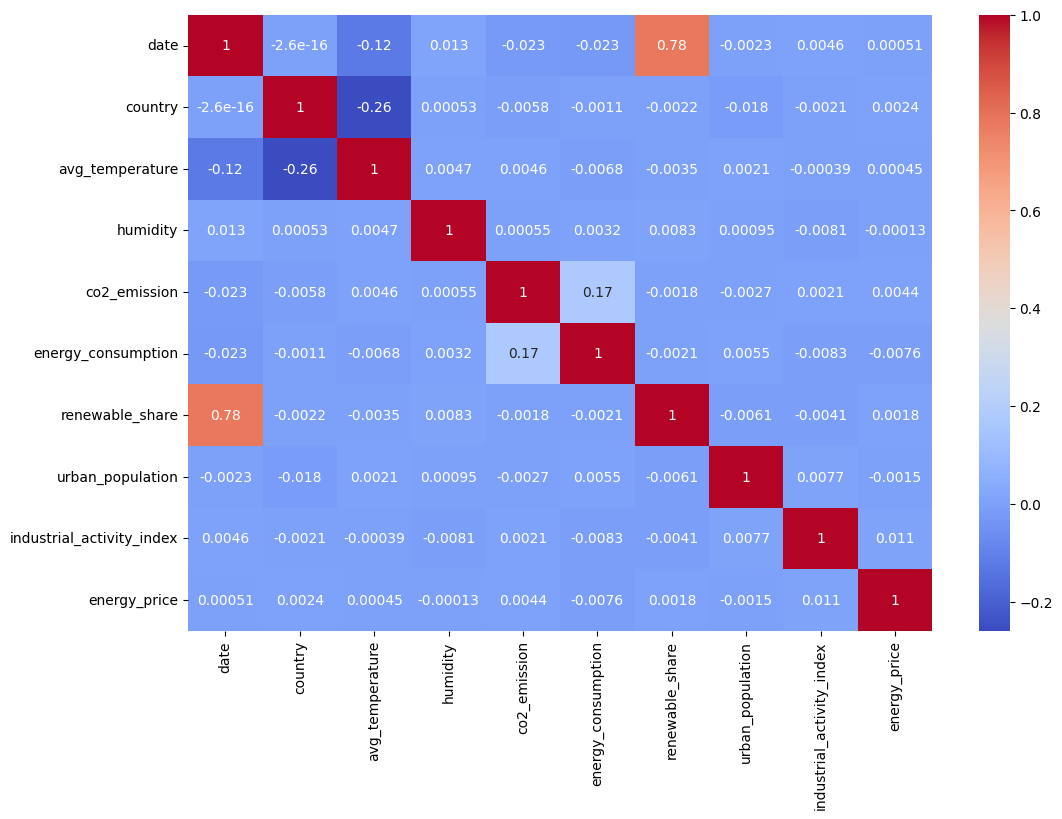

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

scaler = StandardScaler()
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.show()